<a href="https://colab.research.google.com/github/fpellerano/devllm/blob/main/20_3_a_Vector_Databases%2C_Retrieval%2C_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To upload a `requirements.txt` file to your Google Colab environment, follow these steps:

1.  **Open the Files pane**: Click the **Folder icon** in the left-hand sidebar.
2.  **Upload your file**:
    *   **Drag and drop** your file directly into the pane.
    *   **OR** click the **Upload to session storage** icon (a file with an upward arrow) to select it from your local machine.

  
>[IMPORTANT] Files uploaded this way are temporary and will be deleted once the session is recycled.

# Vector Databases, Retrieval, and Embeddings

This notebook builds a **Retrieval-Augmented Generation (RAG)** pipeline from first principles — starting with what embeddings are and ending with a working, evaluated RAG system.

We will cover:
- What **embeddings** are and how they capture semantic meaning as geometry
- How to measure **cosine similarity** between text vectors
- How to **visualize** a high-dimensional embedding space in 3D
- How to do similarity search **by hand**, then with **ChromaDB**
- How to configure a **retriever** (top-k, MMR)
- How to build a RAG chain using **LCEL** step by step
- How to **evaluate** RAG quality with our own LLM-as-judge metrics

**Stack:** Google Gemini (LLM) · HuggingFace sentence-transformers (embeddings) · ChromaDB (vector store) · LangChain / LangGraph

In [ ]:
!pip install -qU -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0

In [ ]:
from google.colab import userdata
import os

google_api_key = userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = google_api_key

## What Are Embeddings?

An **embedding** is a dense vector of floating-point numbers that represents a piece of text.
The key property is that **meaning is captured as geometry**: texts with similar meaning end up
close together in vector space, while semantically unrelated texts are far apart.

For example:
- *"The food was delicious"* and *"The meal tasted amazing"* → vectors pointing in nearly the same direction
- *"The food was delicious"* and *"The service was terrible"* → vectors pointing in very different directions

This is what makes vector search possible: instead of matching keywords, we find documents
that are **semantically close** to a query by measuring the angle between their vectors.

The model we use here (`all-MiniLM-L6-v2`) maps any text into a **384-dimensional** unit vector.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
import numpy as np

embeddings_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"trust_remote_code": False},
)

# Each text becomes a dense vector
sample_vec = embeddings_model.embed_query("Hello, what is a neural network?")
print(f"Embedding dimensions : {len(sample_vec)}")
print(f"First 8 values       : {[round(v, 4) for v in sample_vec[:8]]}")
print(f"Vector norm          : {np.linalg.norm(sample_vec):.6f}  (unit vector -> cosine sim == dot product)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimensions : 384
First 8 values       : [-0.0803, -0.0634, -0.0236, 0.0099, -0.0506, 0.0507, -0.0104, -0.0186]
Vector norm          : 1.000000  (unit vector -> cosine sim == dot product)


## Semantic Similarity

**Cosine similarity** measures the angle between two vectors:
- `1.0` → same direction (identical meaning)
- `0.0` → orthogonal (unrelated)
- `-1.0` → opposite directions

Below we embed a small set of sentences and plot their pairwise cosine similarities as a heatmap.
Notice how sentences about the **same topic** form bright clusters, even when they use completely different words.

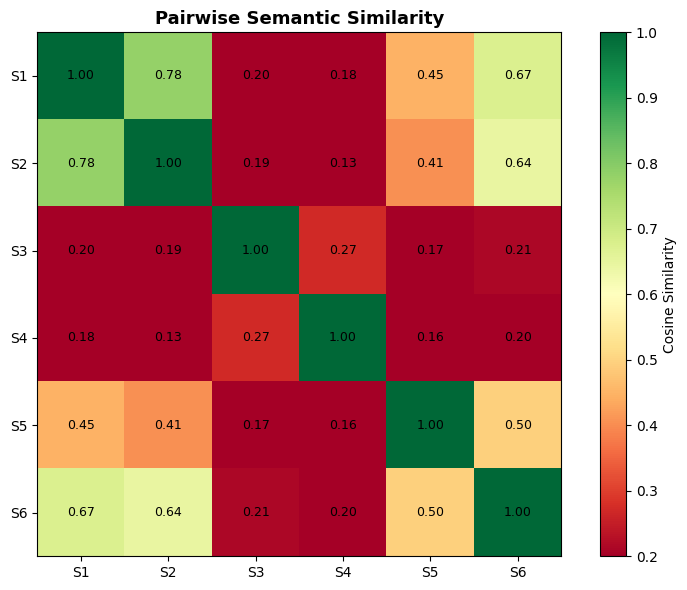


Sentence key:
  S1: The food was absolutely delicious
  S2: The meal tasted amazing and fresh
  S3: The service was extremely slow
  S4: Staff were rude and unhelpful
  S5: The atmosphere was nice and cozy
  S6: The restaurant had a wonderful vibe


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "The food was absolutely delicious",     # S1  food / positive
    "The meal tasted amazing and fresh",     # S2  food / positive
    "The service was extremely slow",        # S3  service / negative
    "Staff were rude and unhelpful",         # S4  service / negative
    "The atmosphere was nice and cozy",      # S5  ambiance / positive
    "The restaurant had a wonderful vibe",   # S6  ambiance / positive
]

vecs = np.array(embeddings_model.embed_documents(sentences))
sim = cosine_similarity(vecs)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim, cmap="RdYlGn", vmin=0.2, vmax=1.0)
plt.colorbar(im, label="Cosine Similarity")

labels = [f"S{i+1}" for i in range(len(sentences))]
ax.set_xticks(range(len(sentences))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(sentences))); ax.set_yticklabels(labels)
ax.set_title("Pairwise Semantic Similarity", fontsize=13, fontweight="bold")

for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSentence key:")
for i, s in enumerate(sentences):
    print(f"  S{i+1}: {s}")

## Loading the Dataset

We use a dataset of **McDonald's Yelp reviews**. Each entry is a short free-text opinion
from a customer — exactly the kind of unstructured data that RAG is designed for.

In [ ]:
import pandas as pd

!wget -q https://raw.githubusercontent.com/Gaalipour/Opinion-Mining-in-Costumer-Reviews-for-McDonalds-Restaurants/master/McDonalds-Yelp-Sentiment-DFE.csv

NUM_REVIEWS = 20
review_texts = (
    pd.read_csv("McDonalds-Yelp-Sentiment-DFE.csv", encoding="ISO-8859-1")["review"]
    .head(NUM_REVIEWS)
    .tolist()
)

print(f"Loaded {len(review_texts)} reviews. Sample:\n")
for i, r in enumerate(review_texts[:3]):
    print(f"  [{i+1}] {r[:110]}...")

Loaded 20 reviews. Sample:

  [1] I'm not a huge mcds lover, but I've been to better ones. This is by far the worst one I've ever been too! It's...
  [2] Terrible customer service. Î¾I came in at 9:30pm and stood in front of the register and no one bothered to say...
  [3] First they "lost" my order, actually they gave it to someone one else than took 20 minutes to figure out why I...


## Visualizing the Embedding Space

Each review is mapped to a 384-dimensional vector — impossible to visualize directly.
We use **Principal Component Analysis (PCA)** to project down to 3 dimensions while
preserving as much of the variance structure as possible.

In the resulting 3D scatter plot:
- Each **blue dot** is a review document
- The **red star** is a query vector

The key intuition: **retrieval is just nearest-neighbor search**. Documents closest
to the query star in this space are the ones the retriever will return.
The closer a document is to the star, the more relevant it is to the query.

Embedding reviews...


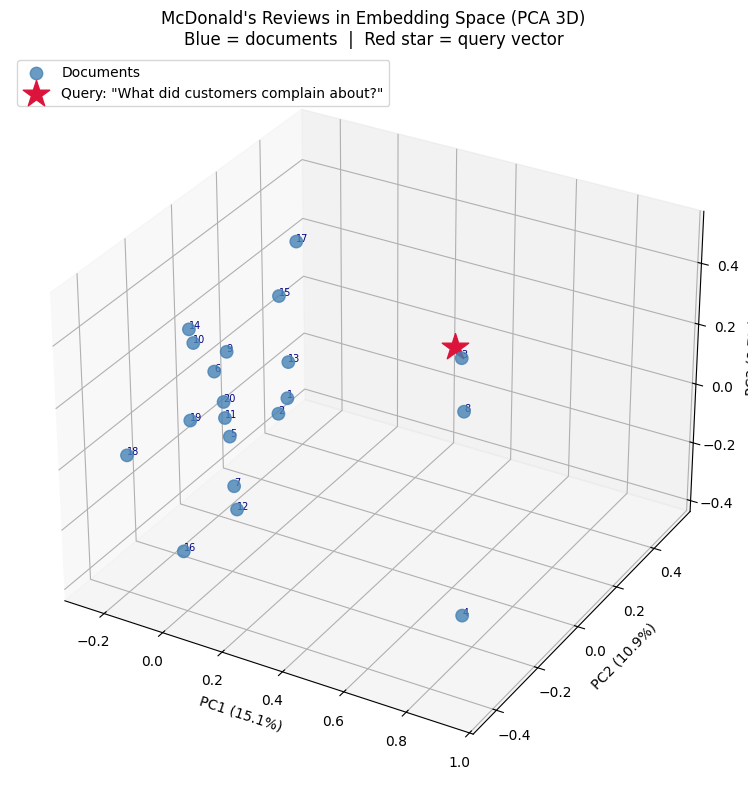

Variance explained by 3 PCs: 34.7%


In [ ]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Embed all reviews
print("Embedding reviews...")
doc_vecs = np.array(embeddings_model.embed_documents(review_texts))

# Choose a query and embed it
query = "What did customers complain about?"
query_vec = np.array(embeddings_model.embed_query(query))

# Fit PCA on all vectors together so docs and query share the same projected space
all_vecs   = np.vstack([doc_vecs, query_vec])
pca        = PCA(n_components=3)
all_coords = pca.fit_transform(all_vecs)

doc_coords  = all_coords[:-1]   # (N, 3)
query_coord = all_coords[-1]    # (3,)

# ── Plot ──
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection="3d")

ax.scatter(
    doc_coords[:, 0], doc_coords[:, 1], doc_coords[:, 2],
    c="steelblue", s=80, alpha=0.8, label="Documents",
)
ax.scatter(
    [query_coord[0]], [query_coord[1]], [query_coord[2]],
    c="crimson", s=400, marker="*", zorder=10, label=f'Query: "{query}"',
)

for i in range(len(review_texts)):
    ax.text(doc_coords[i, 0], doc_coords[i, 1], doc_coords[i, 2],
            str(i + 1), fontsize=7, color="navy")

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var[2]*100:.1f}%)")
ax.set_title(
    "McDonald's Reviews in Embedding Space (PCA 3D)\n"
    "Blue = documents  |  Red star = query vector",
    fontsize=12,
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Variance explained by 3 PCs: {sum(var)*100:.1f}%")

## Manual Similarity Search

Before handing off to a vector database, let's implement retrieval by hand.
This shows exactly what ChromaDB (or any vector store) does internally:

1. Embed the query into a vector
2. Compute cosine similarity between the query vector and **every** document vector
3. Sort by score and return the top-k

This brute-force approach is fine for small datasets.
For millions of documents, vector stores use **Approximate Nearest Neighbor (ANN)** algorithms
(e.g. HNSW, IVF) that are orders of magnitude faster.

In [ ]:
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def manual_search(query, texts, vectors, k=3):
    q_vec  = np.array(embeddings_model.embed_query(query))
    scored = [
        (text, cosine_sim(q_vec, vec))
        for text, vec in zip(texts, vectors)
    ]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:k]

# ── Run a search ──
query = "What did customers complain about?"
results = manual_search(query, review_texts, doc_vecs, k=3)

print(f"Query: {query}\n")
for i, (text, score) in enumerate(results, 1):
    print(f"  [{i}] Similarity: {score:.4f}")
    print(f"       {text[:110]}...")
    print()

Query: What did customers complain about?

  [1] Similarity: 0.5434
       Terrible customer service. Î¾I came in at 9:30pm and stood in front of the register and no one bothered to say...

  [2] Similarity: 0.4501
       This is the worst McDonalds I have ever seen. Î¾The service was terrible and the employees were either lazy or...

  [3] Similarity: 0.4282
       As the previous yelpers have already stated, this place is pretty slow. The food is usually cold.. and the ser...



## ChromaDB Vector Store

Now we hand off the same embedding + search work to **ChromaDB**, a lightweight vector store
that runs in-process (no server needed). It stores document vectors, indexes them for fast
retrieval, and supports metadata filtering.

`Chroma.from_documents()` embeds the documents and builds the index in one step.
The `.similarity_search_with_score()` method returns documents ranked by distance — you should
see the same top results as the manual search above.

In [ ]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_chroma import Chroma
import pandas as pd

# Persist reviews to CSV for LangChain's CSVLoader
pd.Series(review_texts, name="review").to_csv("reviews.csv", index=False)
loader = CSVLoader(file_path="./reviews.csv")
docs   = loader.load()

print("Building ChromaDB vector store...")
docsearch = Chroma.from_documents(docs, embeddings_model)
print(f"Vector store ready. Documents indexed: {docsearch._collection.count()}")

Building ChromaDB vector store...
Vector store ready. Documents indexed: 20


In [ ]:
query   = "What did customers complain about?"
results = docsearch.similarity_search_with_score(query, k=3)

print(f"Query: {query}\n")
for doc, score in results:
    print(f"  Distance: {score:.4f}")
    print(f"  Content : {doc.page_content[:110]}...")
    print()

Query: What did customers complain about?

  Distance: 1.0062
  Content : review: Terrible customer service. Î¾I came in at 9:30pm and stood in front of the register and no one bothere...

  Distance: 1.0335
  Content : review: This is the worst McDonalds I have ever seen. Î¾The service was terrible and the employees were either...

  Distance: 1.0985
  Content : review: As the previous yelpers have already stated, this place is pretty slow. The food is usually cold.. and...



## Retriever Configurations

The vector store exposes a `.as_retriever()` interface that plugs directly into LangChain chains.
Two important knobs:

### `k` — number of documents to retrieve
Higher `k` gives the LLM more context but also more noise. Typical values range from 3 to 10
depending on document length and the LLM's context window.

### Search type: `similarity` vs `mmr`
- **`similarity`**: returns the `k` nearest documents. Can return redundant results if multiple docs say the same thing.
- **`mmr` (Maximum Marginal Relevance)**: balances **relevance** and **diversity**. It iteratively selects
  documents that are relevant to the query *and* dissimilar from already-selected documents.
  Particularly useful when the corpus has many near-duplicate chunks.

In [ ]:
print("=== Effect of k on retrieved documents ===\n")
for k in [1, 3, 5]:
    retriever = docsearch.as_retriever(search_kwargs={"k": k})
    retrieved = retriever.invoke("complaints about food quality")
    print(f"k={k}: {len(retrieved)} doc(s) retrieved")
    for d in retrieved:
        print(f"       {d.page_content[:70]}...")
    print()

=== Effect of k on retrieved documents ===

k=1: 1 doc(s) retrieved
       review: As the previous yelpers have already stated, this place is pre...

k=3: 3 doc(s) retrieved
       review: As the previous yelpers have already stated, this place is pre...
       review: Super slow service, food's terrible like its been sitting and ...
       review: This is the worst McDonalds I have ever seen. Î¾The service wa...

k=5: 5 doc(s) retrieved
       review: As the previous yelpers have already stated, this place is pre...
       review: Super slow service, food's terrible like its been sitting and ...
       review: This is the worst McDonalds I have ever seen. Î¾The service wa...
       review: Terrible customer service. Î¾I came in at 9:30pm and stood in ...
       review: Well, it's McDonald's, so you know what the food is. Î¾This re...



In [ ]:
query_div = "What did customers say about their experience?"

sim_docs = docsearch.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},
).invoke(query_div)

mmr_docs = docsearch.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 10},
).invoke(query_div)

print("=== Similarity (top-3 by score, may be redundant) ===")
for d in sim_docs:
    print(f"  - {d.page_content[:90]}...")

print("\n=== MMR (top-3 maximizing relevance + diversity) ===")
for d in mmr_docs:
    print(f"  - {d.page_content[:90]}...")

=== Similarity (top-3 by score, may be redundant) ===
  - review: This is the worst McDonalds I have ever seen. Î¾The service was terrible and the e...
  - review: As the previous yelpers have already stated, this place is pretty slow. The food i...
  - review: I'm not a huge mcds lover, but I've been to better ones. This is by far the worst ...

=== MMR (top-3 maximizing relevance + diversity) ===
  - review: This is the worst McDonalds I have ever seen. Î¾The service was terrible and the e...
  - review: As the previous yelpers have already stated, this place is pretty slow. The food i...
  - review: Super slow service, food's terrible like its been sitting and then reheated. Î¾Eve...


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    temperature=0.0,
    google_api_key=google_api_key,
)

## Building a RAG Chain with LCEL

Now we wire all the pieces together with LCEL. Building the chain manually
(instead of using the `create_retrieval_chain` helper) makes every step visible and customizable:

```
question
   │
   ├──► retriever ──► format_docs ──► {context}
   │                                       │
   └──────────────────────────────────► {question}
                                            │
                                        rag_prompt
                                            │
                                           llm
                                            │
                                      StrOutputParser
                                            │
                                          answer
```

The `RunnablePassthrough` in the chain passes the raw question string through unchanged
so it reaches `{question}` in the prompt.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


def format_docs(docs):
    # Numbered context block so the LLM can reference individual documents
    return "\n\n".join(
        f"[Document {i+1}]:\n{doc.page_content}"
        for i, doc in enumerate(docs)
    )


rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an assistant for question-answering tasks. "
     "Use ONLY the following retrieved documents to answer the question. "
     "If the documents do not contain enough information, say so clearly.\n\n"
     "Context:\n{context}"),
    ("user", "{question}"),
])

retriever = docsearch.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 10},
)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("RAG chain ready.")

RAG chain ready.


### RAG in Action

Let's run several queries and inspect the full pipeline: retrieved context + generated answer.
Printing the context alongside the answer lets you verify that the LLM is grounded in
the retrieved documents and not fabricating information.

In [ ]:
def ask_rag(question, show_context=True):
    retrieved = retriever.invoke(question)
    context   = format_docs(retrieved)
    answer    = rag_chain.invoke(question)

    print(f"Question: {question}")
    if show_context:
        print("\n--- Retrieved Context ---")
        print(context[:700] + ("..." if len(context) > 700 else ""))
    print("\n--- Answer ---")
    print(answer)
    print("\n" + "=" * 70 + "\n")
    return retrieved, answer


questions = [
    "What did customers complain about most?",
    "Were there any positive reviews about the food?",
    "What did people say about the service speed?",
]

all_results = []
for q in questions:
    docs, ans = ask_rag(q)
    all_results.append({"question": q, "docs": docs, "answer": ans})

Question: What did customers complain about most?

--- Retrieved Context ---
[Document 1]:
review: This is the worst McDonalds I have ever seen. Î¾The service was terrible and the employees were either lazy or incompetent. I will never return to this establishment.

[Document 2]:
review: As the previous yelpers have already stated, this place is pretty slow. The food is usually cold.. and the service....yeah. you guessed it. Poor.

[Document 3]:
review: The drive thru makes them lost a star since my last review.This is one of those two lane drive thrus, and I know that the function of that is so that the orders are not messed up when you get to the window, but almost everytime, the cashier ends up asking me what did I order. Î¾I inquired about that before and was tol...

--- Answer ---
Based on the provided documents, the most frequent complaints concern the quality of service and the drive-thru experience:

*   **Service:** Multiple reviews describe the service as "terrible," "poor," 

## Evaluating the RAG Pipeline

A RAG system has two components to evaluate: **retrieval quality** and **generation quality**.
We implement three lightweight metrics using the **LLM-as-judge** pattern —
the same conceptual approach used by production evaluation frameworks.

| Metric | What it measures |
|---|---|
| **Context Relevance** | What fraction of retrieved documents actually help answer the question? |
| **Faithfulness** | Is the answer grounded in the retrieved context, or is the model adding outside knowledge? |
| **Answer Relevance** | Does the answer actually address what was asked? |

These are deliberately simple implementations. Production use requires larger sample sizes,
more robust prompting, and confidence calibration — but the core idea is the same.

In [ ]:
from langchain_core.messages import HumanMessage


def eval_context_relevance(question, contexts, llm):
    # What fraction of retrieved docs contain information useful for the question?
    scores = []
    for ctx in contexts:
        prompt = (
            f"Does the following document contain information useful for answering the question?\n\n"
            f"Question: {question}\n"
            f"Document: {ctx}\n\n"
            f"Answer with ONLY 'yes' or 'no'."
        )
        reply = llm.invoke([HumanMessage(prompt)]).content.strip().lower()
        scores.append(1 if "yes" in reply else 0)
    return sum(scores) / len(scores), scores


def eval_faithfulness(question, answer, contexts, llm):
    # Is the answer fully supported by the retrieved context (no hallucination)?
    context_str = "\n\n".join(contexts)
    prompt = (
        f"Is the following answer fully supported by the provided context, "
        f"without relying on outside knowledge?\n\n"
        f"Context:\n{context_str}\n\n"
        f"Answer: {answer}\n\n"
        f"Respond with ONLY 'yes' or 'no'."
    )
    reply = llm.invoke([HumanMessage(prompt)]).content.strip().lower()
    return 1.0 if "yes" in reply else 0.0


def eval_answer_relevance(question, answer, llm):
    # Does the answer actually address the question?
    prompt = (
        f"Does the following answer directly address the question asked?\n\n"
        f"Question: {question}\n"
        f"Answer: {answer}\n\n"
        f"Respond with ONLY 'yes' or 'no'."
    )
    reply = llm.invoke([HumanMessage(prompt)]).content.strip().lower()
    return 1.0 if "yes" in reply else 0.0

In [ ]:
from langchain_core.messages import HumanMessage

def extract_text(content):
    """Helper to extract string from content, handling lists of dicts or strings."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for part in content:
            if isinstance(part, str):
                parts.append(part)
            elif isinstance(part, dict) and "text" in part:
                parts.append(part["text"])
        return "".join(parts)
    return str(content)

def eval_context_relevance(question, contexts, llm):
    scores = []
    for ctx in contexts:
        prompt = (
            f"Does the following document contain information useful for answering the question?\n\n"
            f"Question: {question}\n"
            f"Document: {ctx}\n\n"
            f"Answer with ONLY 'yes' or 'no'."
        )
        reply_content = llm.invoke([HumanMessage(prompt)]).content
        reply = extract_text(reply_content).strip().lower()
        scores.append(1 if "yes" in reply else 0)
    return sum(scores) / len(scores), scores

def eval_faithfulness(question, answer, contexts, llm):
    context_str = "\n\n".join(contexts)
    prompt = (
        f"Is the following answer fully supported by the provided context, "
        f"without relying on outside knowledge?\n\n"
        f"Context:\n{context_str}\n\n"
        f"Answer: {answer}\n\n"
        f"Respond with ONLY 'yes' or 'no'."
    )
    reply_content = llm.invoke([HumanMessage(prompt)]).content
    reply = extract_text(reply_content).strip().lower()
    return 1.0 if "yes" in reply else 0.0

def eval_answer_relevance(question, answer, llm):
    prompt = (
        f"Does the following answer directly address the question asked?\n\n"
        f"Question: {question}\n"
        f"Answer: {answer}\n\n"
        f"Respond with ONLY 'yes' or 'no'."
    )
    reply_content = llm.invoke([HumanMessage(prompt)]).content
    reply = extract_text(reply_content).strip().lower()
    return 1.0 if "yes" in reply else 0.0

print(f"{'Question':<46} | {'Ctx Rel':>7} | {'Faith':>7} | {'Ans Rel':>7}")
print("-" * 78)

for item in all_results:
    q      = item["question"]
    docs   = item["docs"]
    answer = item["answer"]
    ctxs   = [d.page_content for d in docs]

    ctx_score, _ = eval_context_relevance(q, ctxs, llm)
    faith_score  = eval_faithfulness(q, answer, ctxs, llm)
    rel_score    = eval_answer_relevance(q, answer, llm)

    q_disp = (q[:44] + "..") if len(q) > 44 else q
    print(f"{q_disp:<46} | {ctx_score:>7.2f} | {faith_score:>7.2f} | {rel_score:>7.2f}")

Question                                       | Ctx Rel |   Faith | Ans Rel
------------------------------------------------------------------------------
What did customers complain about most?        |    1.00 |    1.00 |    1.00
Were there any positive reviews about the fo.. |    0.00 |    1.00 |    1.00
What did people say about the service speed?   |    1.00 |    1.00 |    1.00


## Going Further: RAGAS

The metrics we implemented above capture the core ideas, but **RAGAS** provides a
production-ready evaluation suite with more robust prompts, additional metrics,
and built-in support for batch evaluation with ground-truth references:

| RAGAS metric | Equivalent to |
|---|---|
| `context_precision` | Context Relevance (above) |
| `faithfulness` | Faithfulness (above) |
| `answer_relevancy` | Answer Relevance (above) |
| `context_recall` | How much of the ground-truth answer is covered by retrieved docs |
| `answer_correctness` | Answer accuracy vs. a reference answer |

**Quick start:**
```python
from ragas import EvaluationDataset, evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision

# Build dataset from your RAG outputs, then:
results = evaluate(dataset=evaluation_dataset, metrics=[faithfulness, answer_relevancy])
```

**References:**
- [RAGAS Documentation](https://docs.ragas.io/)
- [RAGAS GitHub](https://github.com/explodinggradients/ragas)
- [RAGAS Metrics Reference](https://docs.ragas.io/en/latest/concepts/metrics/index.html)

## References

- [LangChain: Vector Stores](https://python.langchain.com/docs/concepts/vectorstores/)
- [LangChain: Retrievers](https://python.langchain.com/docs/concepts/retrievers/)
- [LangChain: RAG Tutorial](https://python.langchain.com/docs/tutorials/rag/)
- [ChromaDB Documentation](https://docs.trychroma.com/)
- [Sentence Transformers](https://www.sbert.net/)
- [Understanding Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity)
- [PCA Explained](https://scikit-learn.org/stable/modules/decomposition.html#pca)